# Import Libaries

In [19]:
import kagglehub
import random
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter
from PIL import Image

# 0. Load Data

In [3]:
path = kagglehub.dataset_download(
    "ashwingupta3012/human-faces",
    output_dir="data"
)

DATA_PATH = Path(path)

print("Path to dataset files:", DATA_PATH)

100%|██████████| 1.82G/1.82G [02:14<00:00, 14.6MB/s]

Extracting files...


Path to dataset files: data


# 1. Data Inspection

## Number of files

In [9]:
FULL_PATH = DATA_PATH / "Humans"
image_files = list(FULL_PATH.rglob("*"))

print("Number of files: ", len(image_files))

Number of files:  7219


## Files format

In [14]:
formats = Counter(
    file.suffix.lower()
    for file in image_files
    if file.is_file()
)


image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

non_image_files = [
    file for file in FULL_PATH.rglob("*")
    if file.is_file() and file.suffix.lower() not in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
]

print(formats)
print(f"Non-image files: {len(non_image_files)}")

Counter({'.jpg': 6991, '.png': 150, '.jpeg': 78})
Non-image files: 0


### Info
All files are in a proper format, so there is no need to delete any of them. Different image formats (`.jpg`, `.png`, and `.jpeg`) are not a problem for the GAN, as we can convert all images to the same format during preprocessing.

## Image Verification

In [ ]:
corrupted_files = []

for file in image_files:
    try:
        with Image.open(file) as img:
            img.load()
    except Exception as e:
        corrupted_files.append((file, str(e)))

print(f"Corrupted images: {len(corrupted_files)}")

Corrupted images: 0


### Info
All images were successfully verified, with no corrupted files detected. Therefore, no images need to be removed from the dataset.

## Display a few random images

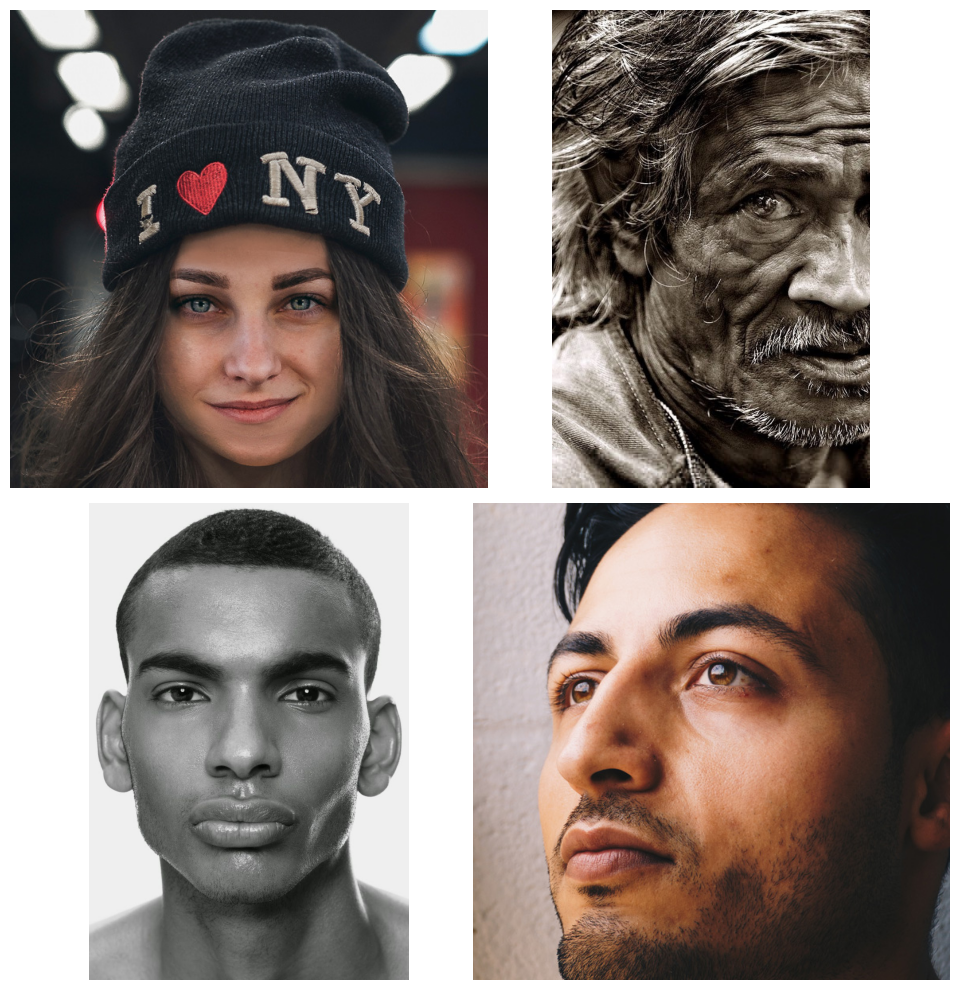

In [23]:
random.seed(42)

sample_images = random.sample(image_files, 4)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, file in zip(axes.flat, sample_images):
    image = Image.open(file).convert("RGB")
    
    ax.imshow(image)
    ax.axis("off")

plt.tight_layout()
plt.show()